# EDA — UAVDT
Detección de objetos desde perspectiva aérea  
Miguel Alejandro Flores Sotelo · Sergio de Jesús Castillo Molano

## Objetivo
Caracterizar el dataset UAVDT antes de usarlo como conjunto de
**validación cruzada**. El EDA de UAVDT es reducido porque no es
el dataset de entrenamiento. El foco es compararlo contra VisDrone
para entender el **domain shift** entre ambos dominios aéreos.

## Fuente
UAVDT-Benchmark-M oficial (Du et al., ECCV 2018):
- 50 secuencias de video (30 train / 20 test)
- 3 clases: car, truck, bus

## Contenido
1. Parseo de anotaciones → DataFrame
2. Distribución de clases
3. Comparativa directa VisDrone vs UAVDT

## 1. Parseo de anotaciones → DataFrame

Se usan las anotaciones oficiales de detección (`*_gt_whole.txt`), una por secuencia:

`frame, target_id, x, y, w, h, out-of-view, occlusion, category`

- Coordenadas en píxeles (esquina superior izquierda + ancho/alto)
- Clases: 1=car, 2=truck, 3=bus
- El split train/test se toma de `M_attr/train` y `M_attr/test`

In [5]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

#Rutas del UAVDT oficial
PROJECT_ROOT=Path("..")
DATASET_ROOT=PROJECT_ROOT/"data"/"uavdt"
FRAMES_DIR=DATASET_ROOT/"UAV-benchmark-M"
GT_DIR=DATASET_ROOT/"UAV-benchmark-MOTD_v1.0"/"GT"
ATTR_DIR=DATASET_ROOT/"M_attr"

#Códigos oficiales de clase (README del toolkit)
CLASS_NAMES={1:"car", 2:"truck", 3:"bus"}

#Carpetas de salida
output_dir=PROJECT_ROOT/"results"/"figures"/"eda_uavdt"
tables_dir=PROJECT_ROOT/"results"/"tables"/"eda_uavdt"
output_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

print(f"Raíz del dataset:{DATASET_ROOT.resolve()}")
print(f"Clases:{CLASS_NAMES}")

Raíz del dataset:/home/magicmike/TT-deteccion-aerea/data/uavdt
Clases:{1: 'car', 2: 'truck', 3: 'bus'}


In [6]:
#Split oficial desde M_attr (strip por el espacio en 'M0701 _attr.txt')
split_map={}
for split in ["train", "test"]:
    for f in (ATTR_DIR/split).glob("*_attr.txt"):
        split_map[f.name.split("_")[0].strip()]=split

#Parsear gt_whole de cada secuencia
cols=["frame", "target_id", "x", "y", "w", "h", "out_of_view", "occlusion", "cat_id"]
dfs=[]
for gt_file in sorted(GT_DIR.glob("*_gt_whole.txt")):
    d=pd.read_csv(gt_file, header=None, names=cols)
    d.insert(0, "seq", gt_file.name.split("_")[0])
    dfs.append(d)

df_u=pd.concat(dfs, ignore_index=True)
df_u["split"]=df_u["seq"].map(split_map)
df_u["class"]=df_u["cat_id"].map(CLASS_NAMES)
df_u["image"]=df_u["seq"]+"_"+df_u["frame"].astype(str).str.zfill(6)

#Resolución (se verifica con el primer frame)
w_img, h_img=Image.open(FRAMES_DIR/"M0101"/"img000001.jpg").size
n_frames=sum(1 for _ in FRAMES_DIR.glob("*/*.jpg"))
n_train=sum(v=="train" for v in split_map.values())
n_test=sum(v=="test" for v in split_map.values())

print(f"Secuencias:{df_u['seq'].nunique()} (train {n_train} / test {n_test})")
print(f"Frames totales:{n_frames:,}")
print(f"Frames con anotaciones:{df_u['image'].nunique():,}")
print(f"Total de detecciones:{len(df_u):,}")
print(f"Resolución:{w_img}x{h_img}")
print(f"Filas sin split:{df_u['split'].isna().sum()}")
print(f"Filas con clase desconocida:{df_u['class'].isna().sum()}")
print()
df_u.head(10)

Secuencias:50 (train 30 / test 20)
Frames totales:40,735
Frames con anotaciones:40,409
Total de detecciones:798,795
Resolución:1024x540
Filas sin split:0
Filas con clase desconocida:0



,seq,frame,target_id,x,y,w,h,out_of_view,occlusion,cat_id,split,class,image
0,M0101,1,1,141,147,106,45,1,1,3,train,bus,M0101_000001
1,M0101,2,1,138,147,106,45,1,1,3,train,bus,M0101_000002
2,M0101,3,1,136,148,106,45,1,1,3,train,bus,M0101_000003
3,M0101,4,1,134,148,106,45,1,1,3,train,bus,M0101_000004
4,M0101,5,1,131,149,106,45,1,1,3,train,bus,M0101_000005
5,M0101,6,1,129,149,106,45,1,1,3,train,bus,M0101_000006
6,M0101,7,1,127,150,106,45,1,1,3,train,bus,M0101_000007
7,M0101,8,1,124,150,106,45,1,1,3,train,bus,M0101_000008
8,M0101,9,1,122,151,106,45,1,1,3,train,bus,M0101_000009
9,M0101,10,1,120,151,106,45,1,1,3,train,bus,M0101_000010


## 2. Distribución de clases

Contamos detecciones por clase para comparar el balance de UAVDT
contra el desbalance severo de VisDrone.

Total detecciones:798,795
Clase mayoritaria:car (755,688)
Clase minoritaria:bus (18,021)
Ratio desbalance :41.9x

       detecciones  porcentaje    test   train
class                                         
car         755688       94.60  361055  394633
truck        25086        3.14    7595   17491
bus          18021        2.26    7234   10787


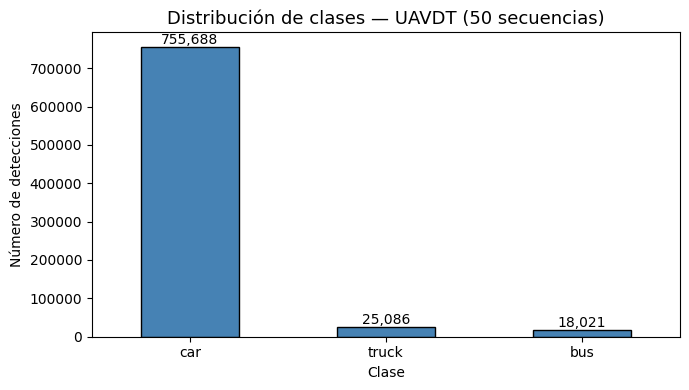

In [7]:
#Distribución de clases
class_counts=df_u["class"].value_counts()
class_pct=(class_counts/len(df_u)*100).round(2)

class_summary=pd.DataFrame({
    "detecciones":class_counts,
    "porcentaje":class_pct
})
#Detecciones por split
class_summary=class_summary.join(pd.crosstab(df_u["class"], df_u["split"]))

ratio=class_counts.max()/class_counts.min()

print(f"Total detecciones:{len(df_u):,}")
print(f"Clase mayoritaria:{class_counts.idxmax()} ({class_counts.max():,})")
print(f"Clase minoritaria:{class_counts.idxmin()} ({class_counts.min():,})")
print(f"Ratio desbalance :{ratio:.1f}x")
print()
print(class_summary)

#Gráfica
fig, ax=plt.subplots(figsize=(7, 4))
class_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Distribución de clases — UAVDT (50 secuencias)", fontsize=13)
ax.set_xlabel("Clase")
ax.set_ylabel("Número de detecciones")
ax.set_xticklabels(class_counts.index, rotation=0)
for i, v in enumerate(class_counts.values):
    ax.text(i, v+class_counts.max()*0.01, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(output_dir/"01_distribucion_clases_uavdt.png", dpi=150, bbox_inches="tight")
plt.show()
class_summary.to_csv(tables_dir/"01_distribucion_clases_uavdt.csv")

## 3. Comparativa VisDrone vs UAVDT

Comparamos los hallazgos clave de ambos datasets para cuantificar
el **domain shift** que el modelo entrenado en VisDrone enfrentará
al evaluarse en UAVDT.

Las clases `car`, `truck` y `bus` son comunes a ambos datasets,
lo que permite evaluación cruzada directa sin reentrenamiento.

In [8]:
#Comparativa VisDrone vs UAVDT
comparativa=pd.DataFrame({
    "Métrica":[
        "Imágenes / frames",
        "Detecciones",
        "Número de clases",
        "Ratio de desbalance",
        "Densidad media (obj/img)",
    ],
    "VisDrone (train)":[
        "6,470",
        "343,171",
        "10",
        "44.7x",
        "53.0",
    ],
    "UAVDT (completo)":[
        f"{df_u['image'].nunique():,}",
        f"{len(df_u):,}",
        "3",
        f"{ratio:.1f}x",
        f"{len(df_u)/df_u['image'].nunique():.1f}",
    ]
})

print(comparativa.to_string(index=False))
comparativa.to_csv(tables_dir/"03_comparativa_visdrone_uavdt.csv", index=False)

                 Métrica VisDrone (train) UAVDT (completo)
       Imágenes / frames            6,470           40,409
             Detecciones          343,171          798,795
        Número de clases               10                3
     Ratio de desbalance            44.7x            41.9x
Densidad media (obj/img)             53.0             19.8
